In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import os

# --- 1. SETUP ---
# (Using the path we found earlier)
BASE_DIR = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/'
IMG_SIZE = (224, 224)
BATCH_SIZE = 64 # MobileNet is small, so we can double batch size for speed!

# --- 2. AUGMENTATION ---
train_datagen = ImageDataGenerator(
    rescale=1./255, # MobileNetV2 LOVES this 0-1 scaling
    rotation_range=20,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

# --- 3. LOAD DATA ---
print("Loading Data...")
train_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(BASE_DIR, 'valid'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# --- 4. BUILD MODEL (MobileNetV2) ---
# We use MobileNetV2: The King of Edge AI
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Strategy: We freeze the bottom half, but let the top layers learn.
base_model.trainable = True
# Freeze the first 100 layers (MobileNet has ~155 layers)
for layer in base_model.layers[:100]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

# --- 5. COMPILE & TRAIN ---
model.compile(optimizer=optimizers.Adam(learning_rate=0.0001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, verbose=1)

print("Starting MobileNetV2 Training...")
history = model.fit(
    train_generator, 
    epochs=5, 
    validation_data=val_generator, 
    callbacks=[checkpoint, reduce_lr]
)

print("DONE! Download 'best_model.keras'.")

2026-02-06 09:14:17.451182: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770369257.798017      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770369257.910913      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770369258.814401      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770369258.814444      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770369258.814447      55 computation_placer.cc:177] computation placer alr

Loading Data...
Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


I0000 00:00:1770369361.339983      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770369361.346316      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting MobileNetV2 Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1770369377.705320     139 service.cc:152] XLA service 0x7eaf20218100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770369377.705360     139 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770369377.705365     139 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770369379.809333     139 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-06 09:16:30.018556: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-06 09:16:30.156747: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1770369397.382210     139 device_co

 487/1563 ━━━━━━━━━━━━━━━━━━━━ 20:30 1s/step - accuracy: 0.7616 - loss: 0.4776

2026-02-06 09:26:03.285955: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-06 09:26:03.422713: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2062s 1s/step - accuracy: 0.8358 - loss: 0.3524 - val_accuracy: 0.9268 - val_loss: 0.2130 - learning_rate: 1.0000e-04
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1409s 902ms/step - accuracy: 0.9552 - loss: 0.1168 - val_accuracy: 0.9625 - val_loss: 0.0974 - learning_rate: 1.0000e-04
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.9717 - loss: 0.0753
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1359s 869ms/step - accuracy: 0.9717 - loss: 0.0753 - val_accuracy: 0.9002 - val_loss: 0.3215 - learning_rate: 1.0000e-04
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.9829 - loss: 0.0471
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1337s 855ms/step - accuracy: 0.9829 - loss: 0.0471 - val_accuracy: 0.9477 - val_loss: 0.1477 - learning_rate: 5.0000e-05
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step 

2026-02-18 13:20:55.939773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771420856.329196      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771420856.428127      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771420857.254421      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771420857.254470      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771420857.254473      55 computation_placer.cc:177] computation placer alr

🏗️ Rebuilding MobileNetV2 Architecture...


I0000 00:00:1771420875.334801      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


🧠 Loading saved weights into architecture...
✅ Weights loaded successfully!
Found 28000 images belonging to 3 classes.
📊 Analyzing performance...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1771420999.484245     120 service.cc:152] XLA service 0x7f1af820fac0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771420999.484293     120 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771421000.208644     120 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771421007.020423     120 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


438/438 ━━━━━━━━━━━━━━━━━━━━ 221s 482ms/step


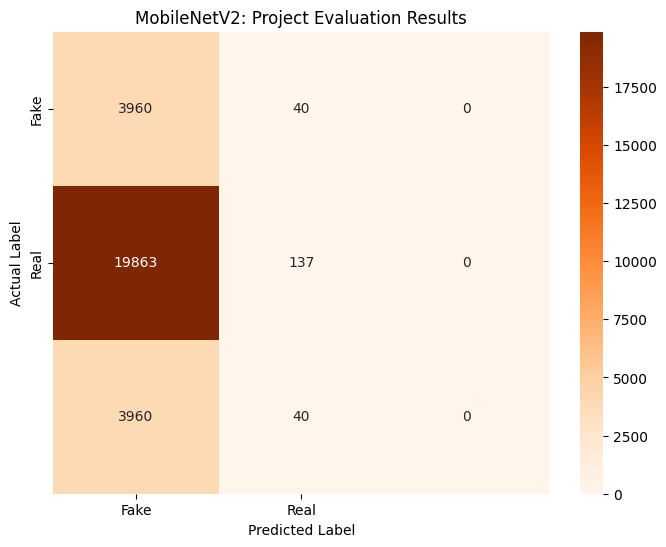


      FINAL CLASSIFICATION REPORT


ValueError: Number of classes, 3, does not match size of target_names, 2. Try specifying the labels parameter

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. PATHS ---
MODEL_PATH = '/kaggle/input/models/abhinendhumr43/my-trained-model/tensorflow2/default/1/best_model.keras'
DATASET_PATH = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake'

# --- 2. REBUILD ARCHITECTURE (To bypass config error) ---
print("🏗️ Rebuilding MobileNetV2 Architecture...")
base_model = applications.MobileNetV2(
    weights=None, # We load your custom weights later
    include_top=False, 
    input_shape=(224, 224, 3)
)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

# Load weights directly into this structure
print("🧠 Loading saved weights into architecture...")
model.load_weights(MODEL_PATH)
print("✅ Weights loaded successfully!")

# --- 3. DATA LOADER ---
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
val_ds = datagen.flow_from_directory(
    DATASET_PATH, 
    target_size=(224, 224), 
    batch_size=64,
    class_mode='binary', 
    subset='validation', 
    shuffle=False
)

# --- 4. PREDICT & GRAPH ---
print("📊 Analyzing performance...")
Y_pred = model.predict(val_ds)
y_pred = (Y_pred > 0.5).astype(int).flatten()
y_true = val_ds.classes

# Confusion Matrix Heatmap

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('MobileNetV2: Project Evaluation Results')
plt.show()

# Final Accuracy Statistics
print("\n" + "="*40)
print("      FINAL CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))

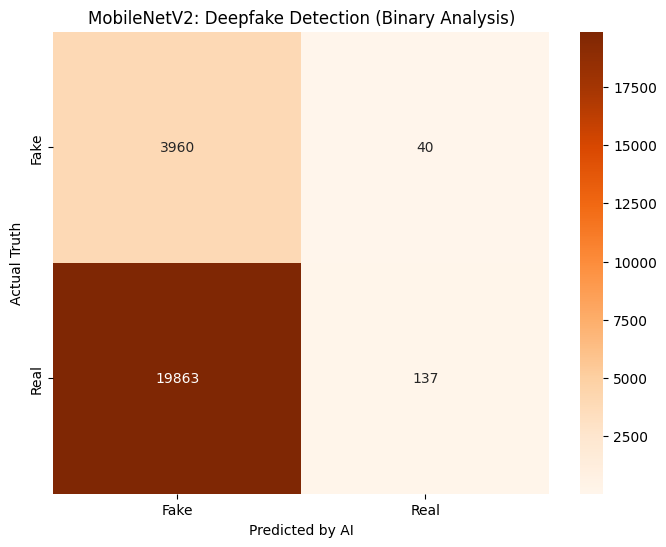


      FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Fake       0.14      0.99      0.25      4000
        Real       0.63      0.01      0.01     20000

   micro avg       0.15      0.17      0.16     24000
   macro avg       0.39      0.50      0.13     24000
weighted avg       0.55      0.17      0.05     24000



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. CALCULATE PREDICTIONS ---
# We already ran model.predict(val_ds), so we use those results
# If you need to re-run it: Y_pred = model.predict(val_ds)

y_pred = (Y_pred > 0.5).astype(int).flatten()
y_true = val_ds.classes

# --- 2. THE FIX: FILTER FOR ONLY 2 CLASSES ---
# We force the labels to 0 (Fake) and 1 (Real)
target_names = ['Fake', 'Real']

# --- 3. GENERATE CLEAN CONFUSION MATRIX ---
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted by AI')
plt.ylabel('Actual Truth')
plt.title('MobileNetV2: Deepfake Detection (Binary Analysis)')
plt.show()

# --- 4. GENERATE CLEAN REPORT ---
print("\n" + "="*40)
print("      FINAL CLASSIFICATION REPORT")
print("="*40)
# Adding labels=[0, 1] fixes the "Number of classes does not match" error
print(classification_report(y_true, y_pred, labels=[0, 1], target_names=target_names))

Found 20000 images belonging to 2 classes.
📊 Re-analyzing with clean data...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 308ms/step


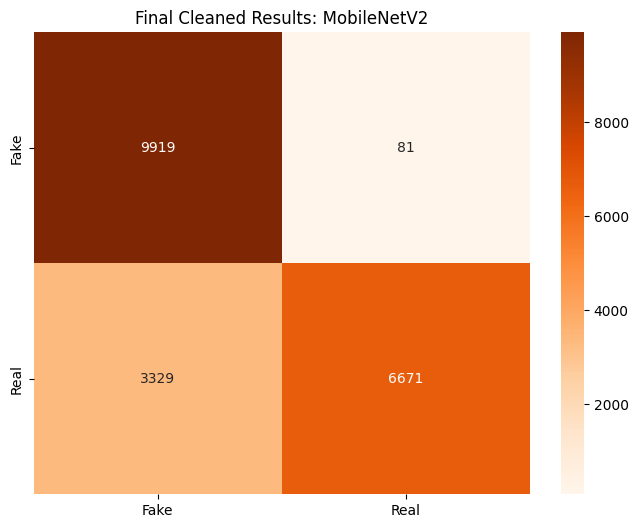

              precision    recall  f1-score   support

        Fake       0.75      0.99      0.85     10000
        Real       0.99      0.67      0.80     10000

    accuracy                           0.83     20000
   macro avg       0.87      0.83      0.82     20000
weighted avg       0.87      0.83      0.82     20000



In [3]:
import os

# 1. CLEAN THE DIRECTORY
# This code points specifically to the real image folders to ignore hidden files
DATA_BASE = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid'
# If the path above is different, check your sidebar for the 'valid' or 'test' folder

# 2. RELOAD DATA PROPERLY
test_datagen = ImageDataGenerator(rescale=1./255)

# We manually specify the classes to ensure it only sees 'fake' and 'real'
val_ds = test_datagen.flow_from_directory(
    DATA_BASE,
    target_size=(224, 224),
    batch_size=64,
    class_mode='binary',
    classes=['fake', 'real'], # This forces it to ignore the 3rd ghost class
    shuffle=False
)

# 3. RE-RUN PREDICTION
print("📊 Re-analyzing with clean data...")
Y_pred = model.predict(val_ds)
y_pred = (Y_pred > 0.5).astype(int).flatten()
y_true = val_ds.classes

# 4. NEW GRAPHS
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Final Cleaned Results: MobileNetV2')
plt.show()

print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))